In [1]:
# ============================================
# Jupyter Script: GP 自动挖掘 + 过滤 + 保存
# ============================================

from factors.factor_auto_search import GeneticFactorGenerator
import pandas as pd

# 1) 初始化 GeneticFactorGenerator（基于你给的参数）
fg = GeneticFactorGenerator(
    instrument_id_list='C0',
    start_time='20200101',
    end_time='20241231',
    version='20260327_gp_test',
    calculate_baseline=True,
    max_factor_count=50,
    rolling_norm_clip=5.0,  # 限制最大杠杆比
    gp_generations=30,
    fitness_metric='sharpe',
    gp_max_depth=4,
    gp_population_size=100,  # 每轮生成的因子数量
    gp_elite_size=20,        # 每轮前gp_elite_size个因子直接保留（不变异）进入下一轮
    gp_leaf_prob=0.3,
    gp_const_prob=0.02,
    gp_window_choices=[5, 10, 20],
    gp_depth_penalty_coef=0.0,
    gp_depth_penalty_start_depth=4,
    gp_depth_penalty_linear_coef=0.05,
    gp_depth_penalty_quadratic_coef=0.0,
    gp_early_stopping_generation_count=8,
    random_seed=42,
    # 新增参数（你要求）
    gp_assumed_initial_capital=100000,
    gp_small_factor_penalty_coef=0.01,
)

# 2) 过滤阈值（沿用项目内日常脚本的默认思路）
filter_indicator_dict = {
    'Net Return': (0.05, 0.03, 1),
    'Net Sharpe': (0.5, 0.3, 1),
}

# 3) 一键执行：自动挖掘 + 筛选 + 保存
result = fg.auto_mine_select_and_save_fc(
    filter_indicator_dict=filter_indicator_dict,
    n_jobs=5,
    require_all_row=True,
    require_all_instruments=True,
)

# 4) 查看结果
print("config_path:", result.get("config_path"))
print("selected_count:", len(result.get("selected_fc_name_list", [])))
print("selected_fc_name_list:", result.get("selected_fc_name_list", []))

bt = result.get("bt")
if bt is not None and getattr(bt, "performance_summary", None) is not None:
    print("\nperformance_summary tail:")
    display(bt.performance_summary.tail(10))

ValueError: apply_weighted_price=True requires external `data` to contain column `open`.

In [10]:
# 总体概括
bt = result['bt']
df_all = bt.performance_summary.loc[bt.performance_summary.index == 'all']
df_all = df_all.sort_values(by='Net Sharpe', ascending=False)
print(len(df_all['Factor Name'].tolist()))
top_fc_name = df_all['Factor Name'].tolist()[:10]
selected_fc_name_list = result['selected_fc_name_list']
print(len(selected_fc_name_list))

50
47


In [11]:
# 检查每年指标
df = bt.performance_summary.loc[bt.performance_summary.index != 'all'].reset_index()
check1 = df.groupby('Factor Name').apply(lambda x: all(x['Net Sharpe'] >= 0.3), include_groups=False).sort_values(ascending=False)
check2 = df.groupby('Factor Name').apply(lambda x: all(x['Net Return'] >= 0.03), include_groups=False).sort_values(ascending=False)
print(check1)

Factor Name
fac_gp_0001     True
fac_gp_0038     True
fac_gp_0027     True
fac_gp_0028     True
fac_gp_0029     True
fac_gp_0030     True
fac_gp_0031     True
fac_gp_0032     True
fac_gp_0034     True
fac_gp_0035     True
fac_gp_0036     True
fac_gp_0039     True
fac_gp_0025     True
fac_gp_0040     True
fac_gp_0042     True
fac_gp_0043     True
fac_gp_0044     True
fac_gp_0045     True
fac_gp_0046     True
fac_gp_0047     True
fac_gp_0048     True
fac_gp_0049     True
fac_gp_0002     True
fac_gp_0026     True
fac_gp_0024     True
fac_gp_0023     True
fac_gp_0003     True
fac_gp_0004     True
fac_gp_0005     True
fac_gp_0006     True
fac_gp_0007     True
fac_gp_0008     True
fac_gp_0009     True
fac_gp_0010     True
fac_gp_0011     True
fac_gp_0012     True
fac_gp_0013     True
fac_gp_0014     True
fac_gp_0015     True
fac_gp_0016     True
fac_gp_0017     True
fac_gp_0018     True
fac_gp_0019     True
fac_gp_0020     True
fac_gp_0021     True
fac_gp_0022     True
fac_gp_0050     True
f

In [12]:
print(check2)

Factor Name
fac_gp_0001     True
fac_gp_0002     True
fac_gp_0028     True
fac_gp_0029     True
fac_gp_0030     True
fac_gp_0031     True
fac_gp_0032     True
fac_gp_0033     True
fac_gp_0034     True
fac_gp_0035     True
fac_gp_0036     True
fac_gp_0037     True
fac_gp_0038     True
fac_gp_0039     True
fac_gp_0040     True
fac_gp_0042     True
fac_gp_0043     True
fac_gp_0044     True
fac_gp_0045     True
fac_gp_0046     True
fac_gp_0047     True
fac_gp_0048     True
fac_gp_0049     True
fac_gp_0027     True
fac_gp_0026     True
fac_gp_0025     True
fac_gp_0024     True
fac_gp_0003     True
fac_gp_0004     True
fac_gp_0005     True
fac_gp_0006     True
fac_gp_0007     True
fac_gp_0008     True
fac_gp_0009     True
fac_gp_0010     True
fac_gp_0011     True
fac_gp_0012     True
fac_gp_0013     True
fac_gp_0014     True
fac_gp_0015     True
fac_gp_0016     True
fac_gp_0017     True
fac_gp_0018     True
fac_gp_0019     True
fac_gp_0020     True
fac_gp_0021     True
fac_gp_0022     True
f

In [13]:
# 检查年化平均指标
check3 = df.groupby('Factor Name')['Net Sharpe'].mean().sort_values(ascending=False)
print(check3)

Factor Name
fac_gp_0001    1.735180
fac_gp_0005    1.735180
fac_gp_0042    1.735180
fac_gp_0002    1.735180
fac_gp_0016    1.721804
fac_gp_0019    1.711657
fac_gp_0036    1.703489
fac_gp_0020    1.700791
fac_gp_0003    1.699457
fac_gp_0038    1.696669
fac_gp_0021    1.695988
fac_gp_0023    1.694175
fac_gp_0004    1.692561
fac_gp_0006    1.676815
fac_gp_0024    1.676815
fac_gp_0026    1.674966
fac_gp_0007    1.670524
fac_gp_0009    1.669599
fac_gp_0028    1.668642
fac_gp_0027    1.668642
fac_gp_0030    1.668642
fac_gp_0029    1.668642
fac_gp_0008    1.668642
fac_gp_0011    1.668114
fac_gp_0010    1.668114
fac_gp_0012    1.668114
fac_gp_0013    1.668114
fac_gp_0014    1.668114
fac_gp_0045    1.668114
fac_gp_0015    1.668114
fac_gp_0043    1.667831
fac_gp_0031    1.666124
fac_gp_0048    1.664024
fac_gp_0049    1.664024
fac_gp_0047    1.664024
fac_gp_0018    1.658205
fac_gp_0017    1.658205
fac_gp_0035    1.656689
fac_gp_0034    1.655926
fac_gp_0032    1.654532
fac_gp_0025    1.648148
fac_

In [14]:
check4 = df.groupby('Factor Name')['Net Return'].mean().sort_values(ascending=False)
print(check4)

Factor Name
fac_gp_0001    0.252899
fac_gp_0005    0.252899
fac_gp_0042    0.252899
fac_gp_0002    0.252899
fac_gp_0016    0.250317
fac_gp_0019    0.249889
fac_gp_0036    0.248168
fac_gp_0023    0.248050
fac_gp_0021    0.247881
fac_gp_0003    0.247802
fac_gp_0020    0.247801
fac_gp_0038    0.247337
fac_gp_0004    0.246659
fac_gp_0009    0.245388
fac_gp_0026    0.245087
fac_gp_0006    0.244827
fac_gp_0024    0.244827
fac_gp_0007    0.244464
fac_gp_0011    0.244391
fac_gp_0045    0.244391
fac_gp_0015    0.244391
fac_gp_0012    0.244391
fac_gp_0013    0.244391
fac_gp_0014    0.244391
fac_gp_0010    0.244391
fac_gp_0008    0.244165
fac_gp_0027    0.244165
fac_gp_0028    0.244165
fac_gp_0029    0.244165
fac_gp_0030    0.244165
fac_gp_0043    0.243850
fac_gp_0031    0.243798
fac_gp_0048    0.243406
fac_gp_0047    0.243406
fac_gp_0049    0.243406
fac_gp_0033    0.243242
fac_gp_0017    0.242455
fac_gp_0018    0.242455
fac_gp_0035    0.242291
fac_gp_0034    0.241753
fac_gp_0022    0.240367
fac_

In [15]:
check5 = df.groupby('Factor Name')['TS IC'].mean().sort_values(ascending=False)
print(check5)

Factor Name
fac_gp_0001    0.108309
fac_gp_0042    0.108309
fac_gp_0002    0.108309
fac_gp_0005    0.108309
fac_gp_0016    0.107635
fac_gp_0038    0.107562
fac_gp_0019    0.107248
fac_gp_0021    0.107060
fac_gp_0036    0.106998
fac_gp_0020    0.106949
fac_gp_0003    0.106924
fac_gp_0023    0.106569
fac_gp_0004    0.106476
fac_gp_0009    0.105876
fac_gp_0006    0.105785
fac_gp_0024    0.105785
fac_gp_0048    0.105714
fac_gp_0049    0.105714
fac_gp_0047    0.105714
fac_gp_0026    0.105670
fac_gp_0013    0.105644
fac_gp_0012    0.105644
fac_gp_0015    0.105644
fac_gp_0014    0.105644
fac_gp_0010    0.105644
fac_gp_0045    0.105644
fac_gp_0011    0.105644
fac_gp_0043    0.105465
fac_gp_0007    0.105342
fac_gp_0008    0.105333
fac_gp_0027    0.105333
fac_gp_0028    0.105333
fac_gp_0029    0.105333
fac_gp_0030    0.105333
fac_gp_0031    0.105115
fac_gp_0018    0.104895
fac_gp_0017    0.104895
fac_gp_0032    0.104872
fac_gp_0035    0.104796
fac_gp_0040    0.104678
fac_gp_0034    0.104573
fac_

In [16]:
# 查看公式
for key, value in fg.factor_formula_map.items():
    print(key, value)
    print('=' * 80)

fac_gp_0001 Neg(TsRankCorr(TsCorr(low, Div(low, position), 5), Sub(open, Div(low, high)), 10))
fac_gp_0002 Neg(TsRankCorr(TsCorr(low, Div(low, position), 5), Sub(Abs(open), Div(low, high)), 10))
fac_gp_0003 Neg(TsRankCorr(TsCorr(low, Div(low, position), 5), Sub(open, Div(low, open)), 10))
fac_gp_0004 Neg(TsRankCorr(TsCorr(low, Div(low, position), 5), Sub(open, Div(close, high)), 10))
fac_gp_0005 Neg(TsRankCorr(TsCorr(low, Div(low, position), 5), Sub(Sub(open, Div(low, high)), Div(low, high)), 10))
fac_gp_0006 Neg(TsRankCorr(TsCorr(low, Div(low, position), 5), Sub(open, Div(open, high)), 10))
fac_gp_0007 Neg(TsRankCorr(TsCorr(low, Div(low, position), 5), Sub(open, Div(close, position)), 10))
fac_gp_0008 Neg(TsRankCorr(TsCorr(low, Div(low, position), 5), Sub(open, Div(low, position)), 10))
fac_gp_0009 Neg(TsRankCorr(TsCorr(low, Div(low, position), 5), Sub(open, Inv(close)), 10))
fac_gp_0010 Neg(TsRankCorr(TsCorr(low, Div(low, position), 5), open, 10))
fac_gp_0011 Neg(TsRankCorr(TsCorr(lo

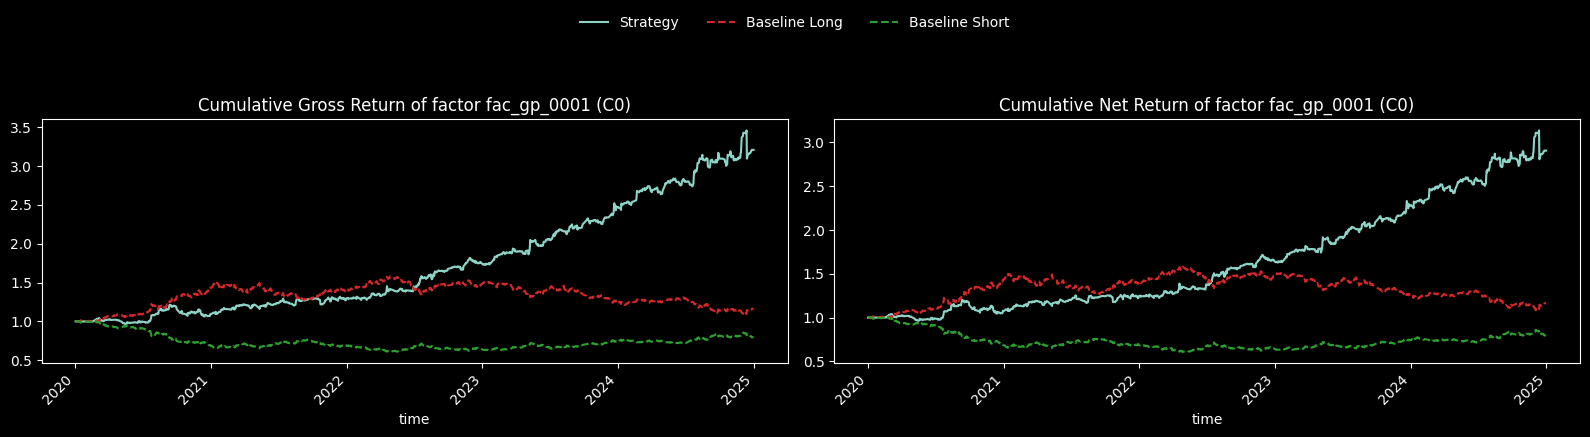

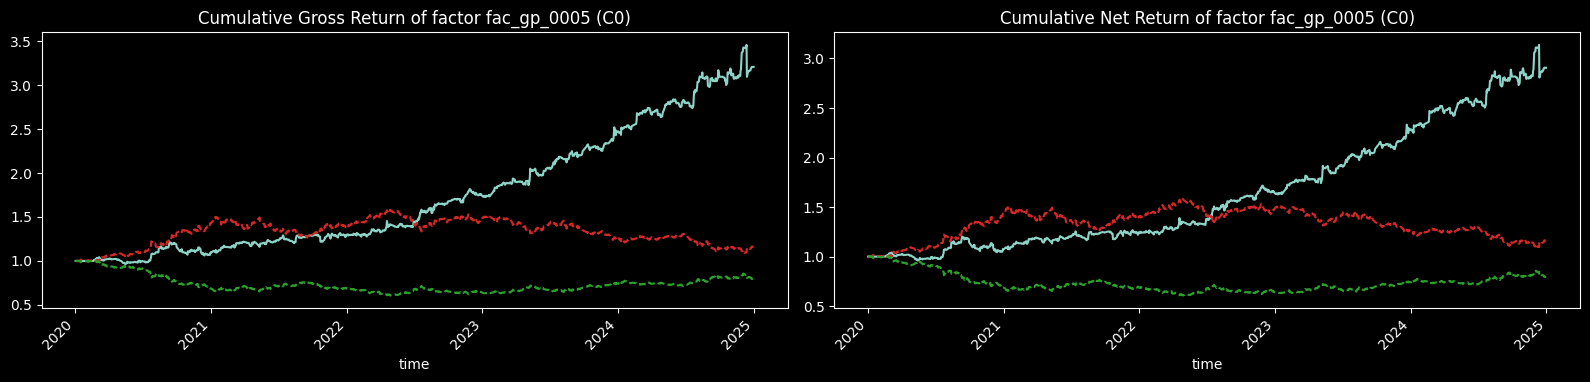

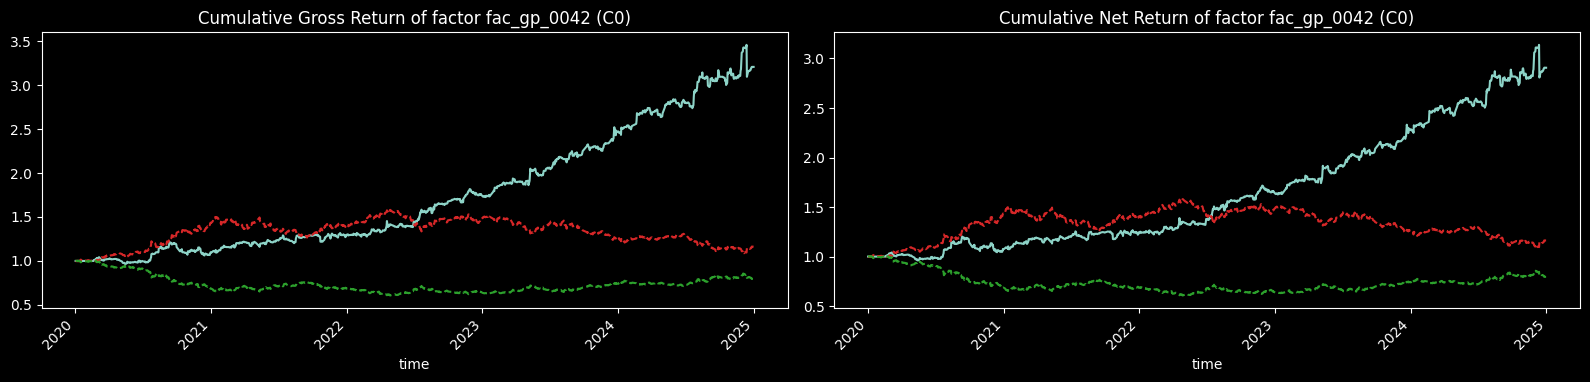

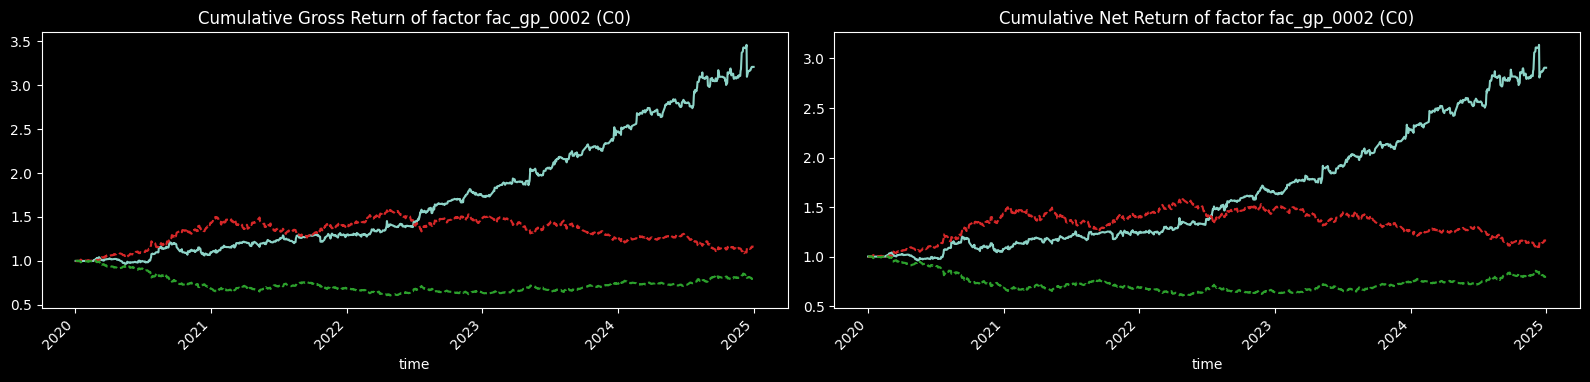

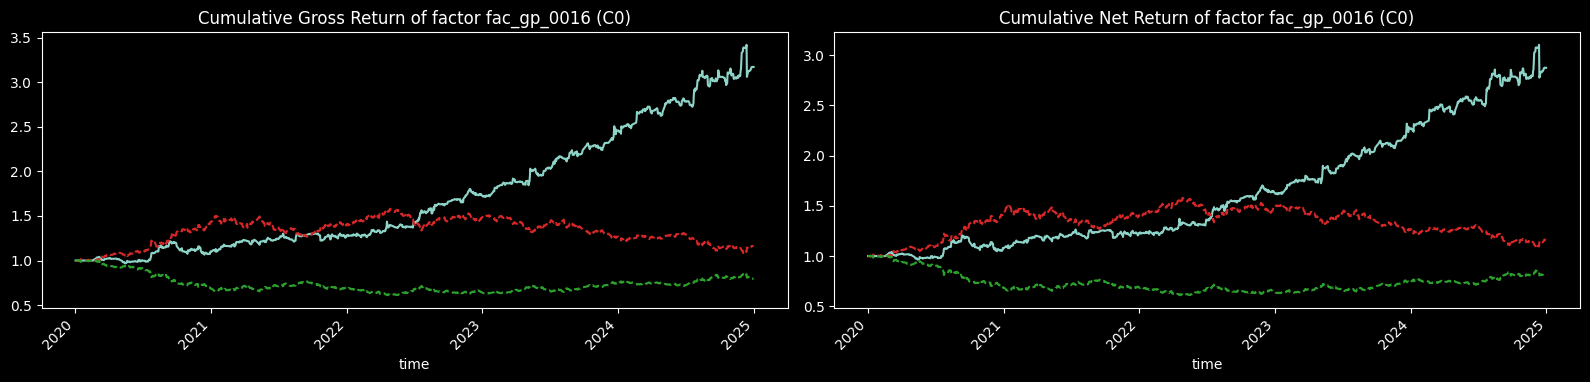

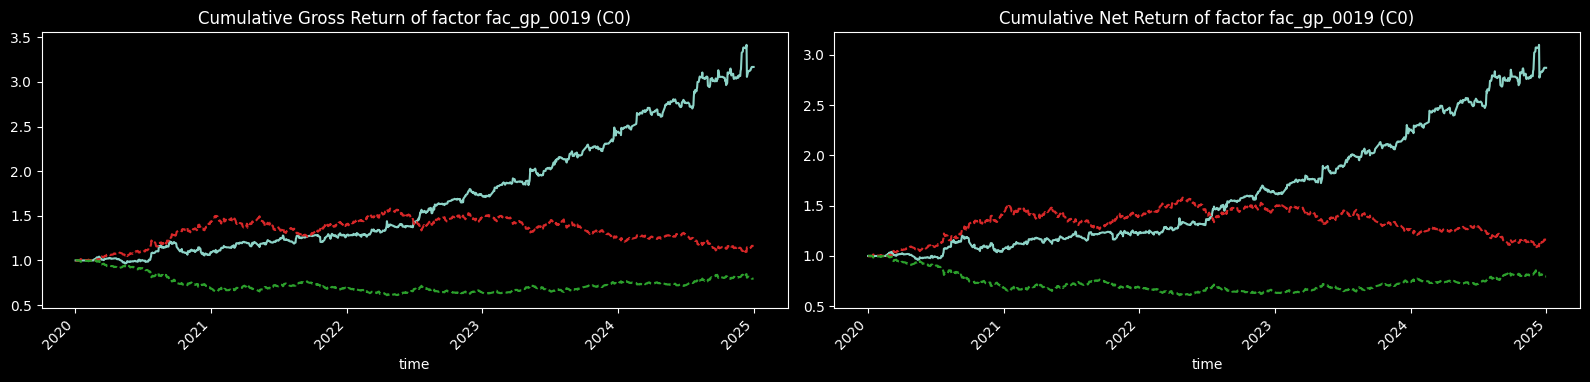

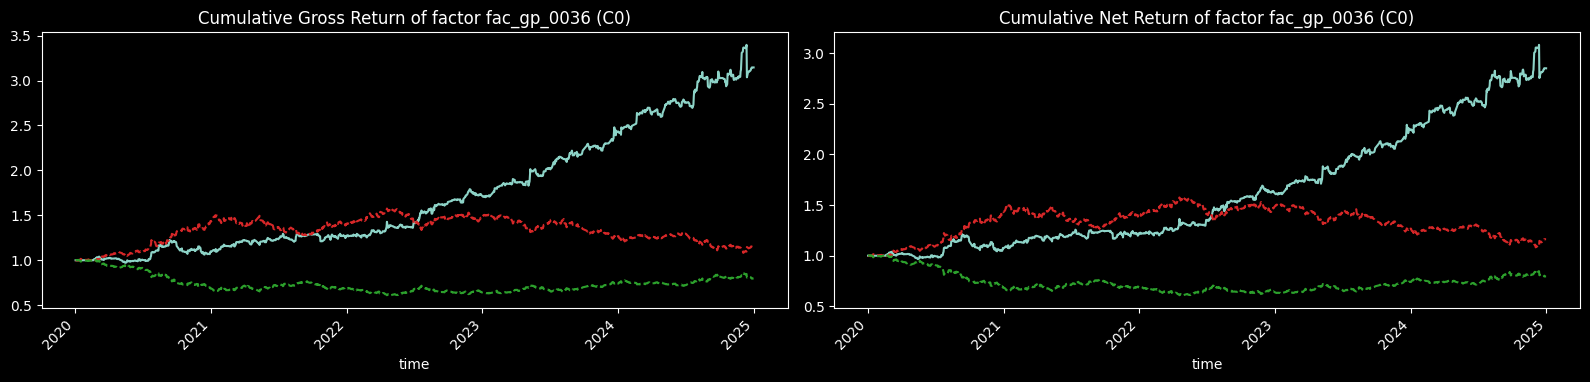

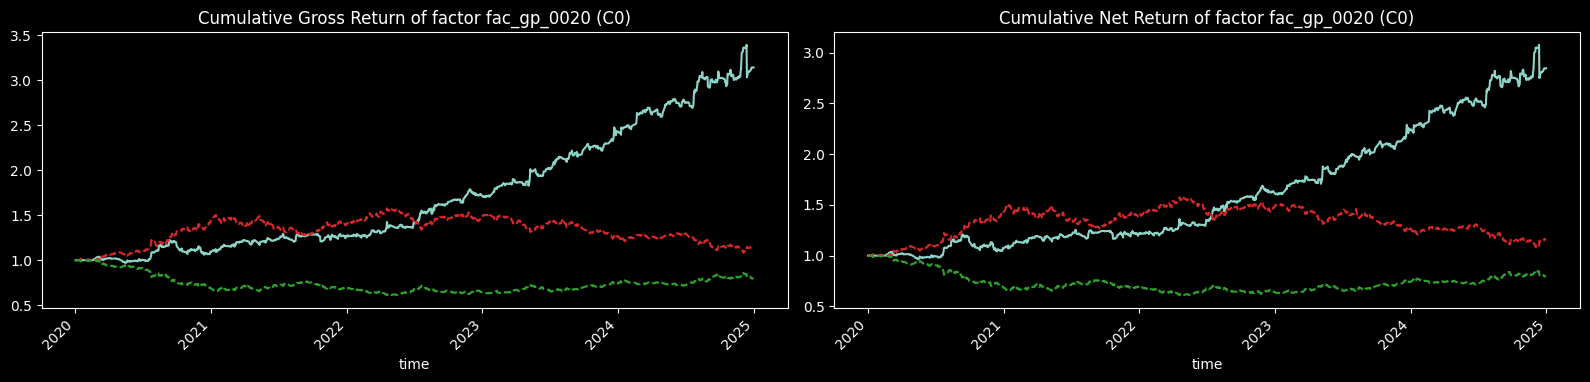

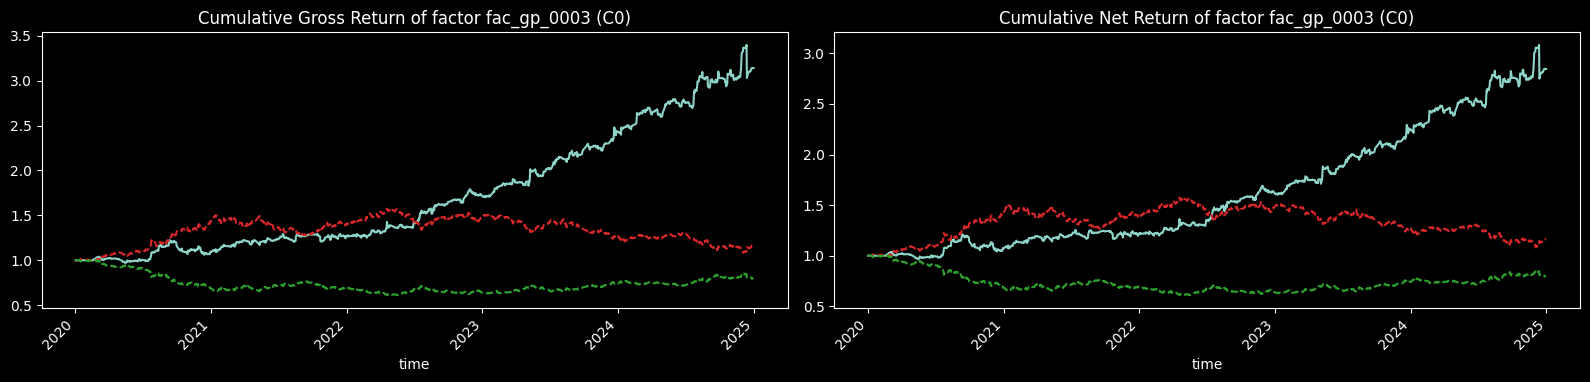

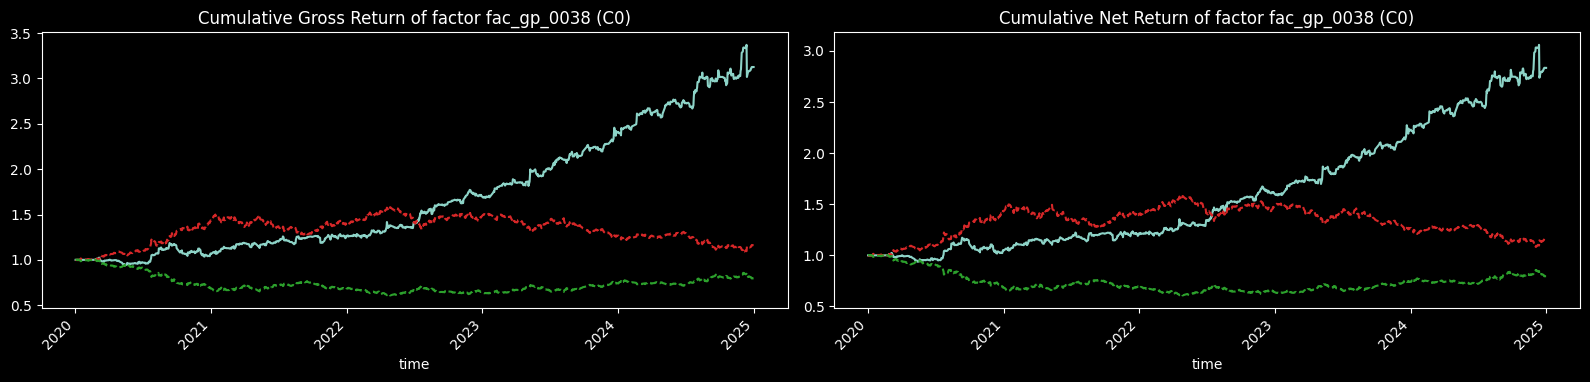

In [17]:
# 净值曲线
start_time = pd.to_datetime('20200101')
end_time = pd.to_datetime('20241231')
bt.plot_nav(start_time=start_time,
            end_time=end_time,
            fc_name=top_fc_name, show_baseline=True)

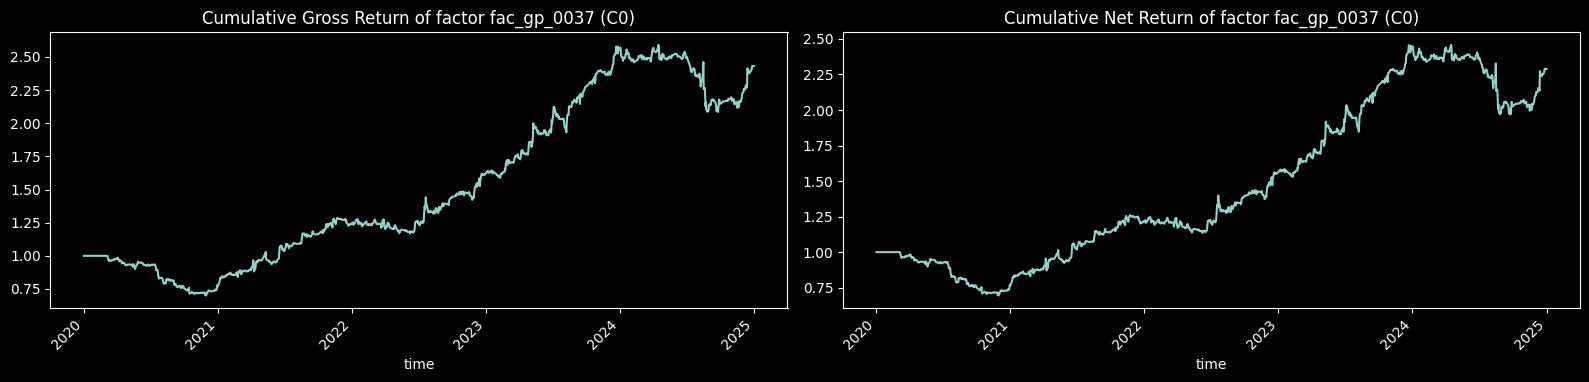

In [10]:
bt.plot_nav(start_time=start_time,
            end_time=end_time,
            fc_name=selected_fc_name_list, show_baseline=False)